<a href="https://colab.research.google.com/github/minato1204love-TTP/Khang_INFO4670_Fall2026/blob/main/INFO4670_Assignment1_Northgate_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — Making Sense of Northgate through Visualization
**INFO 4670 · Data Analysis and Knowledge Discovery**  ·  **Due: Sunday, 11:59 PM**

**Name:** Khang Tran_    **Date:** 9/5/2026

**The situation.** The Provost's question stands: *which students are struggling, and can we see it earlier?* This week you answer it the way analysts do — not by reading rows, but by drawing the data. Every chart below is built by **adapting code from the Guided notebook**; the intellectual work is choosing the right chart and reading it honestly.

**For every chart you make, you must:**
1. **Choose** the chart type that fits the variable(s) and the question.
2. **Build** it in Colab from the Northgate files.
3. **Label** it fully — title, axis labels, and units/legend. *An unlabeled chart is an unfinished chart.*
4. **Write a STAR story** underneath it — Scope · Track · Articulate · Respond (defined on the Concepts deck).

**How to work:** run Setup and Load first. Then, for each question, copy the closest cell from the Guided notebook into the empty cell, adapt it, and fill in the STAR cell below it.

**Submit:** push this notebook to GitHub and submit the **GitHub link** in Canvas. (See the setup doc: *Colab_GitHub_Setup_INFO4670_Fall2026*.)

## Setup — run this first (you don't need to change it)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Northgate house style (optional, but keeps your charts consistent)
NAVY = "#22303A"
RUST = "#C0562F"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]   = (8, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"

## Load the data — run this, then look before you plot

In [30]:
# STEP 1 — get the data into this notebook. Pick ONE option, then run.

DATA_DIR = "/"   # OPTION 2 (default) · drag the 3 CSVs into the file panel on the left

# OPTION 1 · read from Google Drive — uncomment and edit the path:
# from google.colab import drive
# drive.mount("/content/drive")
# DATA_DIR = "/content/drive/MyDrive/.../Data"

import os
students = pd.read_csv(os.path.join(DATA_DIR, "student_records.csv"))
weekly   = pd.read_csv(os.path.join(DATA_DIR, "weekly_activity.csv"))
students.head()

,student_id,major,age,housing,commute_miles,work_hours_per_week,advisor_meetings,credits_attempted,final_gpa,study_hours_reported,enrollment_date,dropped_out
0,NU-101508,Data Science,27,Off-Campus,7.6,15,1,81,1.86,NaN,2023-09-13,1
1,NU-102438,Learning Technologies,25,With Family,14.3,35,1,100,2.06,9.5,2023-10-19,0
2,NU-102385,Learning Technologies,26,With Family,3.4,18,9,77,3.41,19.1,11/16/2022,0
3,NU-100767,Cyber Security,22,On-Campus,23.7,40,1,65,1.73,8.1,2024-05-03,0
4,NU-106054,Information Technology,21,Off-Campus,2.3,20,4,59,2.37,6.6,10/24/2022,0


In [31]:
# how many rows, which columns, what types?
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            2027 non-null   object 
 1   major                 2027 non-null   object 
 2   age                   2027 non-null   int64  
 3   housing               2027 non-null   object 
 4   commute_miles         2027 non-null   float64
 5   work_hours_per_week   2027 non-null   int64  
 6   advisor_meetings      2027 non-null   int64  
 7   credits_attempted     2027 non-null   int64  
 8   final_gpa             2027 non-null   float64
 9   study_hours_reported  1772 non-null   float64
 10  enrollment_date       2027 non-null   object 
 11  dropped_out           2027 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 190.2+ KB


# Part A — Guided questions
Build **one chart per question**. Each maps to one chart family from this week. Copy the closest Guided-notebook cell, adapt it, label it, then write its STAR story.

### Q1 · One quantitative variable
**How many hours per week do Northgate students work?** Describe what's typical, how spread out it is, and whether anyone stands apart.
→ *histogram* (add a *box plot* if it helps). Column: `work_hours_per_week` (from `students`).

In [32]:
students["work_hours_per_week"].describe()

,work_hours_per_week
count,2027.000000
mean,17.284164
std,10.401333
min,-12.000000
25%,10.000000
50%,18.000000
75%,25.000000
max,40.000000


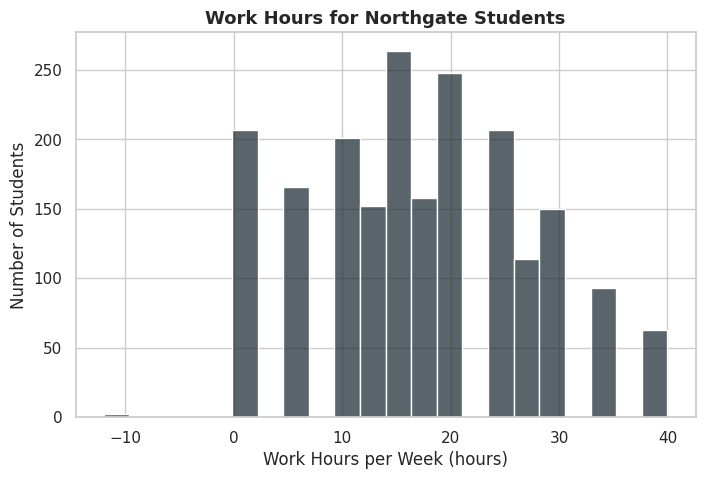

In [33]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
fig, ax = plt.subplots()

sns.histplot(
    data=students,
    x="work_hours_per_week",
    color=NAVY,
    ax=ax
)

ax.set_title("Work Hours for Northgate Students")
ax.set_xlabel("Work Hours per Week (hours)")
ax.set_ylabel("Number of Students")

plt.show()

**STAR story — Q1** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)
- **Track —** which question are you answering?
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

This chart shows the weekly work hours of Northgate students and helps show what is typical and how much work hours vary. Students work about 17 hours per week on average, with a median of 18 hours. The middle 50% of students work between 10 and 25 hours per week. One unusual value is -12 hours, which does not make sense because work hours cannot be negative. I would look into this value later as a possible data quality issue.

### Q2 · One categorical variable
**How does enrollment compare across majors?**
→ *sorted bar chart*. Column: `major` (from `students`).

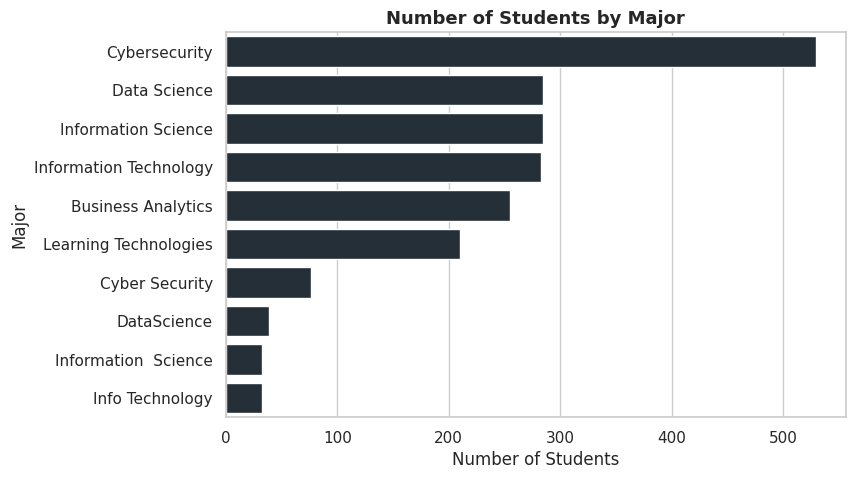

In [34]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
order = students["major"].value_counts().index

fig, ax = plt.subplots()

sns.countplot(
    data=students,
    y="major",
    order=order,
    color=NAVY,
    ax=ax
)

ax.set_title("Number of Students by Major")
ax.set_xlabel("Number of Students")
ax.set_ylabel("Major")

plt.show()

In [35]:
students["major"].value_counts()


,count
major,
Cybersecurity,530
Data Science,285
Information Science,285
Information Technology,283
Business Analytics,255
Learning Technologies,210
Cyber Security,76
DataScience,39
Information Science,32


**STAR story — Q2** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)
- **Track —** which question are you answering?
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

This chart shows the number of Northgate students enrolled in each major and compares enrollment across the majors. Cybersecurity has the highest recorded enrollment with 530 students, followed by Data Science and Information Science with 285 students each. The chart also shows what appear to be duplicate major categories, such as “Cybersecurity” and “Cyber Security,” and “Data Science” and “DataScience.” These differences may be caused by inconsistent naming in the data. I would look at these categories more closely before making a final comparison of enrollment across majors.

### Q3 · A quantity, split by category
**Does final GPA differ across majors?** Read the exceptions, not just the boxes.
→ *box plot per major*. Columns: `final_gpa` and `major` (from `students`).

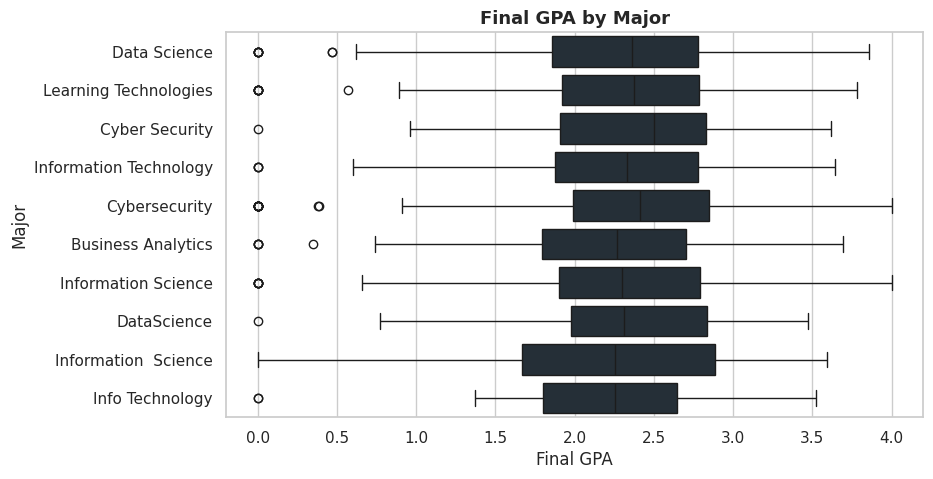

In [36]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=students,
    x="final_gpa",
    y="major",
    color=NAVY,
    ax=ax
)

ax.set_title("Final GPA by Major")
ax.set_xlabel("Final GPA")
ax.set_ylabel("Major")

plt.show()

In [37]:
students.groupby("major")["final_gpa"].describe()

,count,mean,std,min,25%,50%,75%,max
major,,,,,,,,
Business Analytics,255.0,2.244863,0.678391,0.0,1.7950,2.270,2.7050,3.69
Cyber Security,76.0,2.376711,0.693796,0.0,1.9075,2.500,2.8300,3.62
Cybersecurity,530.0,2.352151,0.696768,0.0,1.9900,2.410,2.8475,4.00
Data Science,285.0,2.296211,0.729748,0.0,1.8600,2.360,2.7800,3.86
DataScience,39.0,2.322821,0.735981,0.0,1.9750,2.310,2.8350,3.47
Info Technology,32.0,2.168750,0.786949,0.0,1.8000,2.255,2.6475,3.52
Information Science,32.0,2.270000,0.816855,0.0,1.6675,2.255,2.8850,3.59
Information Science,285.0,2.298667,0.717917,0.0,1.9000,2.300,2.7900,4.00
Information Technology,283.0,2.296714,0.657298,0.0,1.8750,2.330,2.7800,3.64


**STAR story — Q3** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)
- **Track —** which question are you answering?
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

This chart compares the final GPA of Northgate students across different majors. Overall, GPA does not differ much between majors, with median GPAs ranging from about 2.26 to 2.50. Cyber Security has the highest median GPA at 2.50, while Info Technology and the smaller Information Science category have the lowest at about 2.26. An important exception is that every major contains students with a final GPA of 0.00. These zero GPAs stand apart from the regular values and should be investigated further to determine whether they represent actual student performance or a data quality issue.

### Q4 · Two quantitative variables
**Is there a relationship between how far students commute and their final GPA?** Remember: *association is not causation.*
→ *scatterplot with a trend line*. Columns: `commute_miles` and `final_gpa` (from `students`).

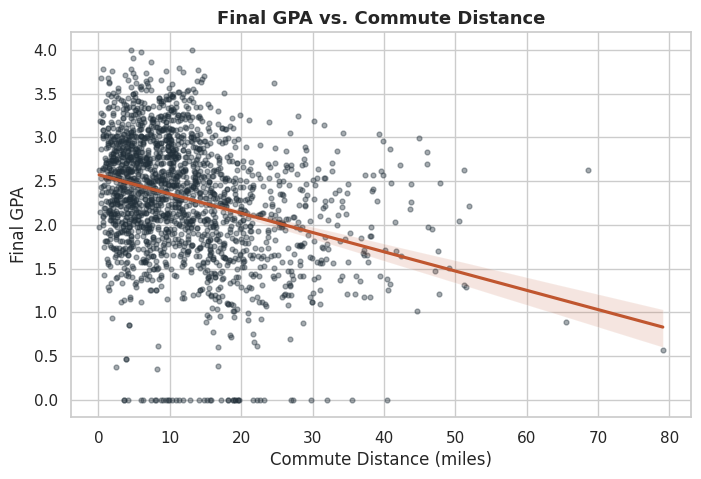

In [38]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
fig, ax = plt.subplots()

sns.regplot(
    data=students,
    x="commute_miles",
    y="final_gpa",
    scatter_kws={"s": 12, "color": NAVY, "alpha": 0.4},
    line_kws={"color": RUST},
    ax=ax
)

ax.set_title("Final GPA vs. Commute Distance")
ax.set_xlabel("Commute Distance (miles)")
ax.set_ylabel("Final GPA")

plt.show()

In [39]:
students[["commute_miles", "final_gpa"]].corr()

,commute_miles,final_gpa
commute_miles,1.000000,-0.295108
final_gpa,-0.295108,1.000000


**STAR story — Q4** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)
- **Track —** which question are you answering?
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

This chart shows the relationship between commute distance and final GPA for Northgate students. The trend line slopes downward, showing that students with longer commutes tend to have lower final GPAs. However, the points are widely spread, so commute distance does not perfectly predict a student's GPA. There are also unusual cases, including several students with a GPA of 0.00 and a few students with very long commutes. I would look more closely at these cases and other factors that may affect GPA. This chart shows an association between commute distance and GPA, but it does not prove that a longer commute causes a lower GPA.

### Q5 · Over time
**How does student engagement change across the semester?**
→ *line chart* of average weekly activity. Use the `weekly` table: `week` and `minutes_active` (you'll need to average by week first — see the Guided notebook).

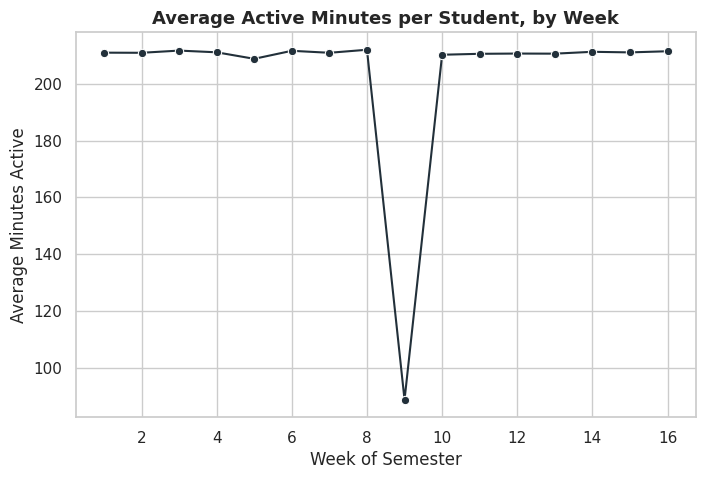

In [40]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
weekly_avg = weekly.groupby("week")["minutes_active"].mean().reset_index()

fig, ax = plt.subplots()

sns.lineplot(
    data=weekly_avg,
    x="week",
    y="minutes_active",
    color=NAVY,
    marker="o",
    ax=ax
)

ax.set_title("Average Active Minutes per Student, by Week")
ax.set_xlabel("Week of Semester")
ax.set_ylabel("Average Minutes Active")

plt.show()

**STAR story — Q5** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)
- **Track —** which question are you answering?
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

This chart shows the average number of minutes Northgate students were active each week during the semester. Student engagement stays fairly consistent at around 210 minutes per week for most of the semester. However, there is a large drop in Week 9, when the average falls to about 90 minutes, before returning to its normal level in Week 10. This sudden decrease stands out from the rest of the semester, so I would look more closely at Week 9 to determine whether there was an event, break, missing data, or another reason for the unusually low activity.

# Part B — Your own question (open)
Pose **one question of your own** about the Northgate students, choose the chart that answers it, build it, label it, and write its STAR story. Going beyond Part A is rewarded — a per-student line chart, a violin plot, or a chart of a messier column are all fair game.

**Your question:** Do students who work more hours per week tend to have lower final GPAs?



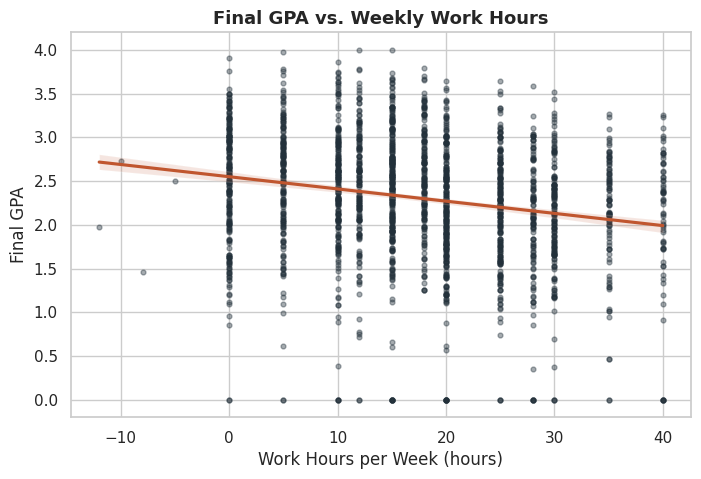

In [41]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
fig, ax = plt.subplots()

sns.regplot(
    data=students,
    x="work_hours_per_week",
    y="final_gpa",
    scatter_kws={"s": 12, "color": NAVY, "alpha": 0.4},
    line_kws={"color": RUST},
    ax=ax
)

ax.set_title("Final GPA vs. Weekly Work Hours")
ax.set_xlabel("Work Hours per Week (hours)")
ax.set_ylabel("Final GPA")

plt.show()

**STAR story — Part B** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)
- **Track —** which question are you answering?
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

This chart shows the relationship between weekly work hours and final GPA for Northgate students. The downward trend line shows that students who work more hours per week tend to have lower final GPAs, although there is a lot of variation between students. The chart also shows some unusual values, including negative work hours and several GPAs of 0.00. I would investigate these unusual values and other factors that may affect GPA before drawing stronger conclusions about the relationship between work hours and academic performance.

# Before you submit — checklist
- [ ] The notebook **runs top to bottom** with no errors (Runtime → Restart and run all).
- [ ] All **6 charts** are present, each with a title, labeled axes, and units/legend where needed.
- [ ] Each chart has a **complete STAR story**, including any exceptions you spotted.
- [ ] Part B question is written in and answered.
- [ ] Pushed to **GitHub**, and the **GitHub link** is submitted in Canvas.

**Rubric (70 pts):** chart choice 10 · correct build 20 · labeling 10 · STAR reading 18 · Part B question 4 · submission & professionalism 8.